## 0. Getting setup

In [ ]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

In [ ]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

## 1. Getting data

In [ ]:
# Mount Google Drive and locate the dataset created by 00_download_prepare_data.ipynb.
from pathlib import Path

try:
    from google.colab import drive
except ImportError as error:
    raise RuntimeError(
        "This setup cell is intended for Google Colab. Open the notebook in Colab "
        "or change DRIVE_DATA_DIR to the local picksense_mini directory."
    ) from error

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/PickSense")
DRIVE_DATA_DIR = PROJECT_DIR / "data" / "picksense_mini"
MODEL_PATH = PROJECT_DIR / "models" / "pretrained_vit_picksense.pth"

if not DRIVE_DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Prepared dataset not found at {DRIVE_DATA_DIR}. "
        "Run 00_download_prepare_data.ipynb first."
    )

print("Dataset found:", DRIVE_DATA_DIR)
print("Model found:", MODEL_PATH.is_file(), MODEL_PATH)

In [ ]:
# Copy the prepared dataset from Drive into this Colab runtime.
# Recreate an incomplete runtime copy so both ImageFolder splits are available.
import shutil

RUNTIME_DATA_DIR = Path("/content/picksense_mini")
TRAIN_DIR = RUNTIME_DATA_DIR / "train"
TEST_DIR = RUNTIME_DATA_DIR / "test"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def count_images(directory):
    if not directory.is_dir():
        return 0
    return sum(
        1
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


source_train_dir = DRIVE_DATA_DIR / "train"
source_test_dir = DRIVE_DATA_DIR / "test"
source_train_count = count_images(source_train_dir)
source_test_count = count_images(source_test_dir)

if source_train_count == 0 or source_test_count == 0:
    raise FileNotFoundError(
        f"Prepared Drive dataset is incomplete: train={source_train_count}, "
        f"test={source_test_count}. Run 00_download_prepare_data.ipynb first."
    )

runtime_complete = count_images(TRAIN_DIR) > 0 and count_images(TEST_DIR) > 0
if runtime_complete:
    print("Complete runtime copy already exists; skipping copy.")
else:
    if RUNTIME_DATA_DIR.exists():
        print("Removing incomplete runtime copy...")
        shutil.rmtree(RUNTIME_DATA_DIR)
    print("Copying complete PickSense dataset from Google Drive...")
    shutil.copytree(DRIVE_DATA_DIR, RUNTIME_DATA_DIR)

train_count = count_images(TRAIN_DIR)
test_count = count_images(TEST_DIR)
if train_count == 0 or test_count == 0:
    raise RuntimeError(
        f"Runtime dataset copy is incomplete: train={train_count}, test={test_count}."
    )

print("Train directory:", TRAIN_DIR)
print("Test directory :", TEST_DIR)
print("Training images:", train_count)
print("Testing images :", test_count)
print("Total images   :", train_count + test_count)

## 2. PickSense EfficientNet-B2 deployment experiment

Train a compact CNN baseline for PickSense's three visual-occlusion classes.

In [ ]:
# 1. Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

# 2. Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# 3. Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights) # could also use weights="DEFAULT"

# 4. Freeze the base layers in the model (this will freeze all layers to begin with)
for param in effnetb2.parameters():
    param.requires_grad = False

In [ ]:
# Check out EffNetB2 classifier head
effnetb2.classifier

In [ ]:
# 5. Update the classifier head
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # keep dropout layer same
    nn.Linear(in_features=1408, # keep in_features same 
              out_features=3)) # change out_features to suit our number of classes

## 3.1 Creating a function to make an EffNetB2 feature extractor

In [ ]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # 1, 2, 3. Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # 5. Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

In [ ]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)

In [ ]:
from torchinfo import summary

 # Print EffNetB2 model summary (uncomment for full output) 
summary(effnetb2, 
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"])

## 3.2 Creating DataLoaders for EffNetB2

In [ ]:
# Setup DataLoaders
from going_modular.going_modular import data_setup

train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=TRAIN_DIR,
                                                                                                 test_dir=TEST_DIR,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

## 3.3 Training EffNetB2 feature extractor

In [37]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set seeds for reproducibility and train the model
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                epochs=10,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                device=device)

## 3.4 Inspecting EffNetB2 loss curves

In [ ]:
from helper_functions import plot_loss_curves

plot_loss_curves(effnetb2_results)


## 3.5 Saving EffNetB2 feature extractor

In [ ]:
from going_modular.going_modular import utils

# Save the PickSense EfficientNet-B2 checkpoint permanently on Google Drive.
EFFNETB2_MODEL_DIR = PROJECT_DIR / "models"
EFFNETB2_MODEL_NAME = "pretrained_effnetb2_picksense.pth"
EFFNETB2_MODEL_PATH = EFFNETB2_MODEL_DIR / EFFNETB2_MODEL_NAME

utils.save_model(
    model=effnetb2,
    target_dir=EFFNETB2_MODEL_DIR,
    model_name=EFFNETB2_MODEL_NAME,
)

print("Saved PickSense model:", EFFNETB2_MODEL_PATH)

## 3.6 Checking the size of EffNetB2 feature extractor 

In [ ]:
# Get the PickSense EfficientNet-B2 model size in megabytes.
if not EFFNETB2_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Model not found at {EFFNETB2_MODEL_PATH}. Run the saving cell first."
    )

pretrained_effnetb2_model_size = EFFNETB2_MODEL_PATH.stat().st_size / (1024 * 1024)
print(f"PickSense EfficientNet-B2 model size: {pretrained_effnetb2_model_size:.1f} MB")

## 3.7 Collecting EffNetB2 feature extractor stats

In [ ]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

In [ ]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats


## 4. Creating a ViT feature extractor

In [ ]:
# Check out ViT heads layer
vit = torchvision.models.vit_b_16()
vit.heads

In [ ]:
def create_vit_model(num_classes:int=3, 
                     seed:int=42):
    """Creates a ViT-B/16 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of target classes. Defaults to 3.
        seed (int, optional): random seed value for output layer. Defaults to 42.

    Returns:
        model (torch.nn.Module): ViT-B/16 feature extractor model. 
        transforms (torchvision.transforms): ViT-B/16 image transforms.
    """
    # Create ViT_B_16 pretrained weights, transforms and model
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)

    # Freeze all layers in model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head to suit our needs (this will be trainable)
    torch.manual_seed(seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, # keep this the same as original model
                                          out_features=num_classes)) # update to reflect target number of classes
    
    return model, transforms

In [ ]:
# Create ViT model and transforms
vit, vit_transforms = create_vit_model(num_classes=3,
                                       seed=42)

In [ ]:
from torchinfo import summary

# # Print ViT feature extractor model summary (uncomment for full output)
summary(vit, 
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"])

## 4.1 Create DataLoaders for ViT

In [ ]:
# Setup ViT DataLoaders
from going_modular.going_modular import data_setup
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=TRAIN_DIR,
                                                                                       test_dir=TEST_DIR,
                                                                                       transform=vit_transforms,
                                                                                       batch_size=32)

## 4.2 Training ViT feature extractor

In [ ]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Train ViT model with seeds set for reproducibility
set_seeds()
vit_results = engine.train(model=vit,
                           train_dataloader=train_dataloader_vit,
                           test_dataloader=test_dataloader_vit,
                           epochs=10,
                           optimizer=optimizer,
                           loss_fn=loss_fn,
                           device=device)

## 4.3 Inspecting ViT loss curves

In [ ]:
from helper_functions import plot_loss_curves

plot_loss_curves(vit_results)

## 4.4 Saving ViT feature extractor

In [ ]:
from going_modular.going_modular import utils

# Save the PickSense EfficientNet-B2 checkpoint permanently on Google Drive.
EFFNETB2_MODEL_DIR = PROJECT_DIR / "models"
EFFNETB2_MODEL_NAME = "pretrained_effnetb2_picksense.pth"
EFFNETB2_MODEL_PATH = EFFNETB2_MODEL_DIR / EFFNETB2_MODEL_NAME

utils.save_model(
    model=effnetb2,
    target_dir=EFFNETB2_MODEL_DIR,
    model_name=EFFNETB2_MODEL_NAME,
)

print("Saved PickSense model:", EFFNETB2_MODEL_PATH)

## 4.5 Checking the size of ViT feature extractor

In [ ]:
# Get the PickSense EfficientNet-B2 model size in megabytes.
if not EFFNETB2_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Model not found at {EFFNETB2_MODEL_PATH}. Run the saving cell first."
    )

pretrained_effnetb2_model_size = EFFNETB2_MODEL_PATH.stat().st_size / (1024 * 1024)
print(f"PickSense EfficientNet-B2 model size: {pretrained_effnetb2_model_size:.1f} MB")

##  4.6 Collecting ViT feature extractor stats

In [ ]:
# Count number of parameters in ViT
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

In [ ]:
# Create ViT statistics dictionary
vit_stats = {"test_loss": vit_results["test_loss"][-1],
             "test_acc": vit_results["test_acc"][-1],
             "number_of_parameters": vit_total_params,
             "model_size (MB)": pretrained_vit_model_size}

vit_stats

## 5. Making predictions with our trained models and timing them

In [ ]:
from pathlib import Path

# Get all test data paths
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {TEST_DIR}")
test_data_paths = list(Path(TEST_DIR).glob("*/*.jpg"))
test_data_paths[:5]

## 5.1 Creating a function to make predictions across the test dataset


Now we've got a list of our test image paths, let's get to work on our pred_and_store() function:

1) Create a function that takes a list of paths, a trained PyTorch model, a series of transforms (to prepare images), a list of target class names and a target device.
2) Create an empty list to store prediction dictionaries (we want the function to return a list of dictionaries, one for each prediction).
3) Loop through the target input paths (steps 4-14 will happen inside the loop).
4) Create an empty dictionary for each iteration in the loop to store prediction values per sample.
5) Get the sample path and ground truth class name (we can do this by inferring the class from the path).
6) Start the prediction timer using Python's timeit.default_timer().
7) Open the image using PIL.Image.open(path).
8) Transform the image so it's capable of being used with the target model as well as add a batch dimension and send the image to the target device.
9) Prepare the model for inference by sending it to the target device and turning on eval() mode.
10) Turn on torch.inference_mode() and pass the target transformed image to the model and calculate the prediction probability using torch.softmax() and the target label using torch.argmax().
11) Add the prediction probability and prediction class to the prediction dictionary created in step 4. Also make sure the prediction probability is on the CPU so it can be used with non-GPU libraries such as NumPy and pandas for later inspection.
12) End the prediction timer started in step 6 and add the time to the prediction dictionary created in step 4.
13) See if the predicted class matches the ground truth class from step 5 and add the result to the prediction dictionary created in step 4.
14) Append the updated prediction dictionary to the empty list of predictions created in step 2.
15) Return the list of prediction dictionaries.





In [ ]:
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer 
from tqdm.auto import tqdm
from typing import List, Dict

# 1. Create a function to return a list of dictionaries with sample, truth label, prediction, prediction probability and prediction time
def pred_and_store(paths: List[pathlib.Path], 
                   model: torch.nn.Module,
                   transform: torchvision.transforms, 
                   class_names: List[str], 
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:
    
    # 2. Create an empty list to store prediction dictionaries
    pred_list = []
    
    # 3. Loop through target paths
    for path in tqdm(paths):
        
        # 4. Create empty dictionary to store prediction information for each sample
        pred_dict = {}

        # 5. Get the sample path and ground truth class name
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name
        
        # 6. Start the prediction timer
        start_time = timer()
        
        # 7. Open image path
        img = Image.open(path)
        
        # 8. Transform the image, add batch dimension and put image on target device
        transformed_image = transform(img).unsqueeze(0).to(device) 
        
        # 9. Prepare model for inference by sending it to target device and turning on eval() mode
        model.to(device)
        model.eval()
        
        # 10. Get prediction probability, predicition label and prediction class
        with torch.inference_mode():
            pred_logit = model(transformed_image) # perform inference on target sample 
            pred_prob = torch.softmax(pred_logit, dim=1) # turn logits into prediction probabilities
            pred_label = torch.argmax(pred_prob, dim=1) # turn prediction probabilities into prediction label
            pred_class = class_names[pred_label.cpu()] # hardcode prediction class to be on CPU

            # 11. Make sure things in the dictionary are on CPU (required for inspecting predictions later on) 
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class
            
            # 12. End the timer and calculate time per pred
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time, 4)

        # 13. Does the pred match the true label?
        pred_dict["correct"] = class_name == pred_class

        # 14. Add the dictionary to the list of preds
        pred_list.append(pred_dict)
    
    # 15. Return list of prediction dictionaries
    return pred_list

## 5.2 Making and timing predictions with EffNetB2

In [ ]:
# Make predictions across test dataset with EffNetB2
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device="cpu") # make predictions on CPU 

In [ ]:
# Inspect the first 2 prediction dictionaries
effnetb2_test_pred_dicts[:2]

In [ ]:
# Turn the test_pred_dicts into a DataFrame
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

In [ ]:
# Check number of correct predictions
effnetb2_test_pred_df.correct.value_counts()

In [ ]:
# Find the average time per prediction 
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

In [ ]:
# Add EffNetB2 average prediction time to stats dictionary 
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats


## 5.3 Making and timing predictions with ViT

In [ ]:
# Make list of prediction dictionaries with ViT feature extractor model on test images
vit_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                     model=vit,
                                     transform=vit_transforms,
                                     class_names=class_names,
                                     device="cpu")

In [ ]:
# Check the first couple of ViT predictions on the test dataset
vit_test_pred_dicts[:2]

In [ ]:
# Turn vit_test_pred_dicts into a DataFrame
import pandas as pd
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

In [ ]:
# Count the number of correct predictions
vit_test_pred_df.correct.value_counts()

In [ ]:
# Calculate average time per prediction for ViT model
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
print(f"ViT average time per prediction: {vit_average_time_per_pred} seconds")

In [ ]:
# Add average prediction time for ViT model on CPU
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats

## 6. Comparing model results, prediction times and size

In [ ]:
# Turn stat dictionaries into DataFrame
df = pd.DataFrame([effnetb2_stats, vit_stats])

# Add column for model names
df["model"] = ["EffNetB2", "ViT"]

# Convert accuracy to percentages
df["test_acc"] = round(df["test_acc"] * 100, 2)

df

In [ ]:
# Compare ViT to EffNetB2 across different characteristics
pd.DataFrame(data=(df.set_index("model").loc["ViT"] / df.set_index("model").loc["EffNetB2"]), # divide ViT statistics by EffNetB2 statistics
             columns=["ViT to EffNetB2 ratios"]).T

## 6.1 Visualizing the speed vs. performance tradeoff


In [ ]:
# Visualize the PickSense model speed, accuracy, and size trade-off.
from pathlib import Path

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    data=df,
    x="time_per_pred_cpu",
    y="test_acc",
    c=["#21a179", "#09598c"],
    s=df["model_size (MB)"] * 8,
    alpha=0.75,
    edgecolors="white",
    linewidths=1.5,
)

ax.set_title("PickSense: Inference Speed vs Test Accuracy", fontsize=18, weight="bold")
ax.set_xlabel("CPU prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.25)

for _, row in df.iterrows():
    ax.annotate(
        row["model"],
        xy=(row["time_per_pred_cpu"], row["test_acc"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=12,
        weight="bold",
    )

legend_handles = [
    ax.scatter([], [], s=size * 8, color="gray", alpha=0.5, label=f"{size:.0f} MB")
    for size in sorted(df["model_size (MB)"].unique())
]
ax.legend(
    handles=legend_handles,
    loc="lower right",
    title="Model size",
    fontsize=11,
)

# Create the output directory with Python and save using the PickSense name.
image_dir = Path("images")
image_dir.mkdir(parents=True, exist_ok=True)
figure_path = image_dir / "picksense-inference-speed-vs-accuracy.jpg"
plt.tight_layout()
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
print("Saved PickSense comparison figure:", figure_path)
plt.show()

## 7. Bringing PickSense to life with a Gradio demo

In [ ]:
# Import/install Gradio 
try:
    import gradio as gr
except: 
    !pip -q install gradio
    import gradio as gr
    
print(f"Gradio version: {gr.__version__}")

## 7.1 Gradio overview

`uploaded object image → PickSense EfficientNet-B2 → occlusion probabilities`

The demo classifies each image as **clear**, **partially occluded**, or **heavily occluded**.

## 7.2 Creating a function to map our inputs and outputs

`input image → EfficientNet-B2 preprocessing → PickSense prediction → class probabilities and inference time`

In [ ]:
# Put EffNetB2 on CPU
effnetb2.to("cpu") 

# Check the device
next(iter(effnetb2.parameters())).device

In [ ]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

In [ ]:
import random
from PIL import Image

# Get a list of all test image filepaths
test_data_paths = list(Path(TEST_DIR).glob("*/*.jpg"))

# Randomly select a test image path
random_image_path = random.sample(test_data_paths, k=1)[0]

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

## 7.3 Creating a list of example images

In [ ]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

## 7.4 Building a Gradio interface

`input image → PickSense EfficientNet-B2 → clear/partial/heavy probabilities + prediction time`

In [ ]:
import gradio as gr

# PickSense interface text.
title = "PickSense — Visual Occlusion Classifier"
description = (
    "Upload an object image. The PickSense EfficientNet-B2 model estimates whether "
    "the object is clear, partially occluded, or heavily occluded."
)
article = (
    "PickSense uses visual occlusion as a proxy for pickability. It does not yet "
    "measure grasp geometry, reachability, collision risk, or physical grasp success."
)

# Create the Gradio demo.
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Object image"),
    outputs=[
        gr.Label(num_top_classes=3, label="Occlusion probabilities"),
        gr.Number(label="Prediction time (seconds)"),
    ],
    examples=example_list,
    title=title,
    description=description,
    article=article,
)

# Launch the demo and create a temporary public URL when supported.
demo.launch(debug=False, share=True)

## 8. Turning our PickSense Gradio Demo into a deployable app

## 8.1 What is Hugging Face Spaces?
Hugging Face Spaces is a resource that allows you to host and share machine learning apps.

Building a demo is one of the best ways to showcase and test what you've done.

And Spaces allows you to do just that.

You can think of Hugging Face as the GitHub of machine learning.

If having a good GitHub portfolio showcases your coding abilities, having a good Hugging Face portfolio can showcase your machine learning abilities.

Note: There are many other places we could upload and host our Gradio app such as, Google Cloud, AWS (Amazon Web Services) or other cloud vendors, however, we're going to use Hugging Face Spaces due to the ease of use and wide adoption by the machine learning community.

## 8.2 Deployed Gradio app structure

```text
demos/
└── picksense/
    ├── pretrained_effnetb2_picksense.pth
    ├── app.py
    ├── examples/
    │   ├── clear_example.jpg
    │   ├── heavily_occluded_example.jpg
    │   └── partially_occluded_example.jpg
    ├── model.py
    └── requirements.txt
```

This self-contained folder contains the trained PickSense model, Gradio application, model-building code, representative examples, and runtime dependencies required for deployment.

## 8.3 Creating a demo folder for the deployable PickSense app

In [ ]:
import shutil
from pathlib import Path

# Create a clean folder for the deployable PickSense Gradio app.
picksense_demo_path = Path("demos/picksense")

if picksense_demo_path.exists():
    shutil.rmtree(picksense_demo_path)

picksense_demo_path.mkdir(parents=True, exist_ok=True)

print("PickSense demo directory:", picksense_demo_path.resolve())
print("Current contents:", list(picksense_demo_path.iterdir()))

## 8.4 Creating example images for the PickSense demo

In [ ]:
import random
import shutil

# Create a clean examples directory inside the deployable PickSense app.
picksense_examples_path = picksense_demo_path / "examples"
if picksense_examples_path.exists():
    shutil.rmtree(picksense_examples_path)
picksense_examples_path.mkdir(parents=True, exist_ok=True)

# Select one representative test image from each PickSense class.
random.seed(42)
picksense_examples = []
for class_name in class_names:
    class_images = [
        path
        for path in (TEST_DIR / class_name).iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    if not class_images:
        raise FileNotFoundError(f"No test images found for class: {class_name}")
    picksense_examples.append(random.choice(class_images))

# Copy the selected images into the app's examples directory.
for example_path in picksense_examples:
    destination = picksense_examples_path / f"{example_path.parent.name}_{example_path.name}"
    shutil.copy2(example_path, destination)
    print(f"Copied {example_path} -> {destination}")

print(f"Prepared {len(picksense_examples)} PickSense example images.")

In [ ]:
# Build Gradio example paths relative to the deployable app directory.
example_list = [
    [str(Path("examples") / example_path.name)]
    for example_path in sorted(picksense_examples_path.iterdir())
    if example_path.is_file() and example_path.suffix.lower() in IMAGE_EXTENSIONS
]

if not example_list:
    raise FileNotFoundError(f"No example images found in {picksense_examples_path}")

print(f"Prepared {len(example_list)} Gradio examples:")
example_list

## 8.5 Copying the trained PickSense EfficientNet-B2 model into the demo directory

In [ ]:
import shutil

# Copy the trained PickSense EfficientNet-B2 checkpoint into the deployable app.
picksense_model_source = EFFNETB2_MODEL_PATH
picksense_model_destination = picksense_demo_path / EFFNETB2_MODEL_NAME

if not picksense_model_source.is_file():
    raise FileNotFoundError(
        f"PickSense checkpoint not found at {picksense_model_source}. "
        "Run the EfficientNet-B2 saving cell first."
    )

# Use copy rather than move so the original checkpoint remains on Google Drive.
shutil.copy2(picksense_model_source, picksense_model_destination)

source_size = picksense_model_source.stat().st_size
destination_size = picksense_model_destination.stat().st_size
if source_size != destination_size:
    raise IOError("The copied PickSense checkpoint size does not match the source.")

print(f"Copied PickSense checkpoint: {picksense_model_source}")
print(f"Deployment checkpoint: {picksense_model_destination}")
print(f"Checkpoint size: {destination_size / (1024 * 1024):.1f} MB")

## 8.6 Creating the PickSense EfficientNet-B2 model module (`model.py`)

In [ ]:
%%writefile demos/picksense/model.py
"""Model factory for the deployable PickSense EfficientNet-B2 classifier."""

import torch
import torchvision
from torch import nn


def create_effnetb2_model(num_classes: int = 3, seed: int = 42):
    """Create the PickSense EfficientNet-B2 architecture and preprocessing.

    The model is initialized without downloaded weights because the complete
    trained PickSense state dictionary is loaded by app.py.

    Args:
        num_classes: Number of PickSense occlusion classes.
        seed: Random seed used when constructing the classifier head.

    Returns:
        A tuple containing the EfficientNet-B2 model and image transforms.
    """
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()

    # Avoid downloading ImageNet weights during deployment startup.
    model = torchvision.models.efficientnet_b2(weights=None)

    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )

    return model, transforms

## 8.7 Turning the PickSense Gradio demo into a Python script (`app.py`)

The deployable application script will contain four parts:

1. **Imports and class names** — Import PyTorch, Gradio, PIL, timing utilities, and `create_effnetb2_model()` from `model.py`. Define the PickSense classes in training order: `clear`, `heavily_occluded`, and `partially_occluded`.
2. **Model and transforms** — Recreate the three-class EfficientNet-B2 model, load `pretrained_effnetb2_picksense.pth` with `map_location="cpu"`, and place the model in evaluation mode so the app works without a GPU.
3. **Prediction function** — Preprocess an uploaded image, run inference, convert logits into class probabilities, and return both the probability dictionary and prediction time.
4. **Gradio interface** — Build the PickSense upload interface, load example paths from the local `examples/` directory, and call `demo.launch()` for Hugging Face Spaces.

All deployment paths are relative to `demos/picksense/`, making the folder self-contained and portable.

In [ ]:
%%writefile demos/picksense/app.py
"""Gradio application for the PickSense visual occlusion classifier."""

from pathlib import Path
from timeit import default_timer as timer

import gradio as gr
import torch
from PIL import Image

from model import create_effnetb2_model


APP_DIR = Path(__file__).resolve().parent
MODEL_PATH = APP_DIR / "pretrained_effnetb2_picksense.pth"
EXAMPLES_DIR = APP_DIR / "examples"
CLASS_NAMES = ["clear", "heavily_occluded", "partially_occluded"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Recreate the architecture and load the trained PickSense parameters on CPU.
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=len(CLASS_NAMES)
)
state_dict = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
effnetb2.load_state_dict(state_dict)
effnetb2.eval()


def predict(image: Image.Image) -> tuple[dict[str, float], float]:
    """Return PickSense class probabilities and CPU inference time."""
    if image is None:
        raise ValueError("Upload an image before running prediction.")

    start_time = timer()
    image_tensor = effnetb2_transforms(image.convert("RGB")).unsqueeze(0)

    with torch.inference_mode():
        probabilities = torch.softmax(effnetb2(image_tensor), dim=1)[0]

    predictions = {
        class_name: float(probabilities[index])
        for index, class_name in enumerate(CLASS_NAMES)
    }
    prediction_time = round(timer() - start_time, 5)
    return predictions, prediction_time


example_list = [
    [str(path)]
    for path in sorted(EXAMPLES_DIR.iterdir())
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

TITLE = "PickSense — Visual Occlusion Classifier"
DESCRIPTION = (
    "Upload an object image. PickSense uses an EfficientNet-B2 model to estimate "
    "whether the object is clear, partially occluded, or heavily occluded."
)
ARTICLE = (
    "PickSense uses visual occlusion as a proxy for pickability. It does not yet "
    "measure grasp geometry, reachability, collision risk, or physical grasp success."
)

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Object image"),
    outputs=[
        gr.Label(num_top_classes=3, label="Occlusion probabilities"),
        gr.Number(label="Prediction time (seconds)"),
    ],
    examples=example_list,
    title=TITLE,
    description=DESCRIPTION,
    article=ARTICLE,
)


if __name__ == "__main__":
    demo.launch()

## 8.8 Creating the PickSense deployment requirements (`requirements.txt`)

These versions match the environment used to generate and test the PickSense Gradio application.

In [ ]:
%%writefile demos/picksense/requirements.txt
torch==2.11.0
torchvision==0.26.0
gradio==6.26.0
Pillow==11.3.0

## 9. Deploying the PickSense app to Hugging Face Spaces

The deployable files are contained in `demos/picksense/`. Create a new **Gradio** Space and upload the contents of that directory so `app.py`, `model.py`, `requirements.txt`, the trained checkpoint, and `examples/` are all at the repository root.

Two deployment options are available:

1. **Hugging Face web interface** — Create a Space and upload the PickSense files in the browser. This is the simplest option.
2. **Git or the Hugging Face CLI** — Clone the Space repository, copy in the PickSense files, commit them, and push.

The `huggingface_hub` Python package can also create and upload the Space programmatically. After upload, Spaces installs `requirements.txt` and starts the Gradio application from `app.py`.

## 9.1 Packaging and downloading the PickSense app

The following cells package `demos/picksense/` as `demos/picksense.zip`, save a persistent backup in Google Drive, and start a browser download to the computer's normal **Downloads** folder when running in Google Colab.

After running the packaging cell, approve the browser download if prompted. The browser—not Python—controls the final local download location.

In [ ]:
!ls demos/picksense

In [ ]:
import shutil
from pathlib import Path
from zipfile import ZIP_DEFLATED, ZipFile

# Package the self-contained PickSense app for Hugging Face Spaces.
picksense_demo_path = Path("demos/picksense")
picksense_zip_path = Path("demos/picksense.zip")
required_files = {
    "app.py",
    "model.py",
    "requirements.txt",
    "pretrained_effnetb2_picksense.pth",
}

if not picksense_demo_path.is_dir():
    raise FileNotFoundError(
        f"Deployment directory not found: {picksense_demo_path}. Run section 8 first."
    )

missing_files = sorted(
    filename
    for filename in required_files
    if not (picksense_demo_path / filename).is_file()
)
if missing_files:
    raise FileNotFoundError(
        "The PickSense deployment folder is incomplete. Missing: "
        + ", ".join(missing_files)
    )

excluded_parts = {"__pycache__", ".ipynb_checkpoints"}
excluded_suffixes = {".pyc", ".ipynb"}
with ZipFile(picksense_zip_path, mode="w", compression=ZIP_DEFLATED) as archive:
    for path in sorted(picksense_demo_path.rglob("*")):
        if (
            path.is_file()
            and not excluded_parts.intersection(path.parts)
            and path.suffix.lower() not in excluded_suffixes
        ):
            archive.write(path, arcname=path.relative_to(picksense_demo_path))

archive_size_mb = picksense_zip_path.stat().st_size / (1024 * 1024)
print(f"Created deployment archive: {picksense_zip_path.resolve()}")
print(f"Archive size: {archive_size_mb:.1f} MB")

# Keep a persistent copy in Google Drive.
picksense_drive_zip_path = PROJECT_DIR / "deployments" / picksense_zip_path.name
picksense_drive_zip_path.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(picksense_zip_path, picksense_drive_zip_path)
print(f"Google Drive backup: {picksense_drive_zip_path}")

# Download a separate copy to this computer through the browser.
try:
    from google.colab import files
except ImportError:
    from IPython.display import FileLink, display

    print("Use the link below to download the ZIP to this computer:")
    display(FileLink(str(picksense_zip_path)))
else:
    print("Starting browser download to this computer...")
    files.download(str(picksense_zip_path))

## 9.2 Running our PickSense demo locally

If you download the picksense.zip file, you can test it locally by:

1. Unzipping the file.
2. Opening terminal or a command line prompt.
3. Changing into the picksense directory (cd picksense).
4. Creating an environment (python3 -m venv env).
5. Activating the environment (source env/bin/activate).
6. Installing the requirements (pip install -r requirements.txt, the "-r" is for recursive).
   Note: This step may take 5-10 minutes depending on your internet connection. And if you're facing errors, you may need to upgrade pip first: pip install --upgrade pip.
7. Run the app (python3 app.py).


## 9.3 Uploading directly from Google Colab to Hugging Face Spaces

The ZIP file is **not required**. The next cell uploads the complete `demos/picksense/` directory directly from the Colab runtime.

1. Create a Hugging Face account if needed.
2. Open **Settings → Access Tokens** on Hugging Face and create a token with **write** permission.
3. Set `HF_USERNAME` to the Hugging Face username and choose a Space name.
4. Run the upload cell.
5. When the secure Hugging Face login widget appears, paste the token there. Do not write the token directly into notebook code.
6. The cell creates or updates a public Gradio Space and prints its URL.

Rerun the same cell whenever the deployment files change; it uploads the latest version without needing a local download.

In [ ]:
# Authenticate securely with Hugging Face. Do not paste the token into notebook code.
try:
    from huggingface_hub import notebook_login
except ImportError:
    !pip install -q -U huggingface_hub
    from huggingface_hub import notebook_login

notebook_login()

In [ ]:
# Create or update the PickSense Space using the account authenticated above.
from huggingface_hub import HfApi

HF_SPACE_NAME = "picksense"
HF_SPACE_PRIVATE = False

if not picksense_demo_path.is_dir():
    raise FileNotFoundError(
        f"Deployment folder not found at {picksense_demo_path}. Run section 8 first."
    )

api = HfApi()
account = api.whoami()
hf_username = account["name"]
space_repo_id = f"{hf_username}/{HF_SPACE_NAME}"

print(f"Authenticated Hugging Face account: {hf_username}")
print(f"Uploading folder: {picksense_demo_path.resolve()}")

api.create_repo(
    repo_id=space_repo_id,
    repo_type="space",
    space_sdk="gradio",
    space_hardware="cpu-basic",
    private=HF_SPACE_PRIVATE,
    exist_ok=True,
)

# Existing Spaces keep their previous hardware, so explicitly select CPU Basic.
# PickSense performs CPU inference and does not need ZeroGPU or @spaces.GPU.
api.request_space_hardware(
    repo_id=space_repo_id,
    hardware="cpu-basic",
)

api.upload_folder(
    repo_id=space_repo_id,
    repo_type="space",
    folder_path=str(picksense_demo_path),
    commit_message="Upload PickSense Gradio app",
    ignore_patterns=["__pycache__/*", "*.pyc", ".ipynb_checkpoints/*"],
)

runtime = api.get_space_runtime(space_repo_id)
print(
    f"Space runtime: stage={runtime.stage}, hardware={runtime.hardware}, "
    f"requested={runtime.requested_hardware}"
)
print(f"PickSense Space uploaded: https://huggingface.co/spaces/{space_repo_id}")

In [ ]:
from IPython.display import IFrame, display

# Replace YOUR_USERNAME after deploying the PickSense Space.
HF_USERNAME = "YOUR_USERNAME"
HF_SPACE_NAME = "picksense"

if HF_USERNAME == "YOUR_USERNAME":
    print(
        "Set HF_USERNAME to your Hugging Face username, then rerun this cell "
        "to embed the deployed PickSense app."
    )
else:
    space_embed_url = f"https://{HF_USERNAME}-{HF_SPACE_NAME}.hf.space"
    print("Embedding PickSense Space:", space_embed_url)
    display(IFrame(src=space_embed_url, width="100%", height=750))

## 10. Creating PickSense Big

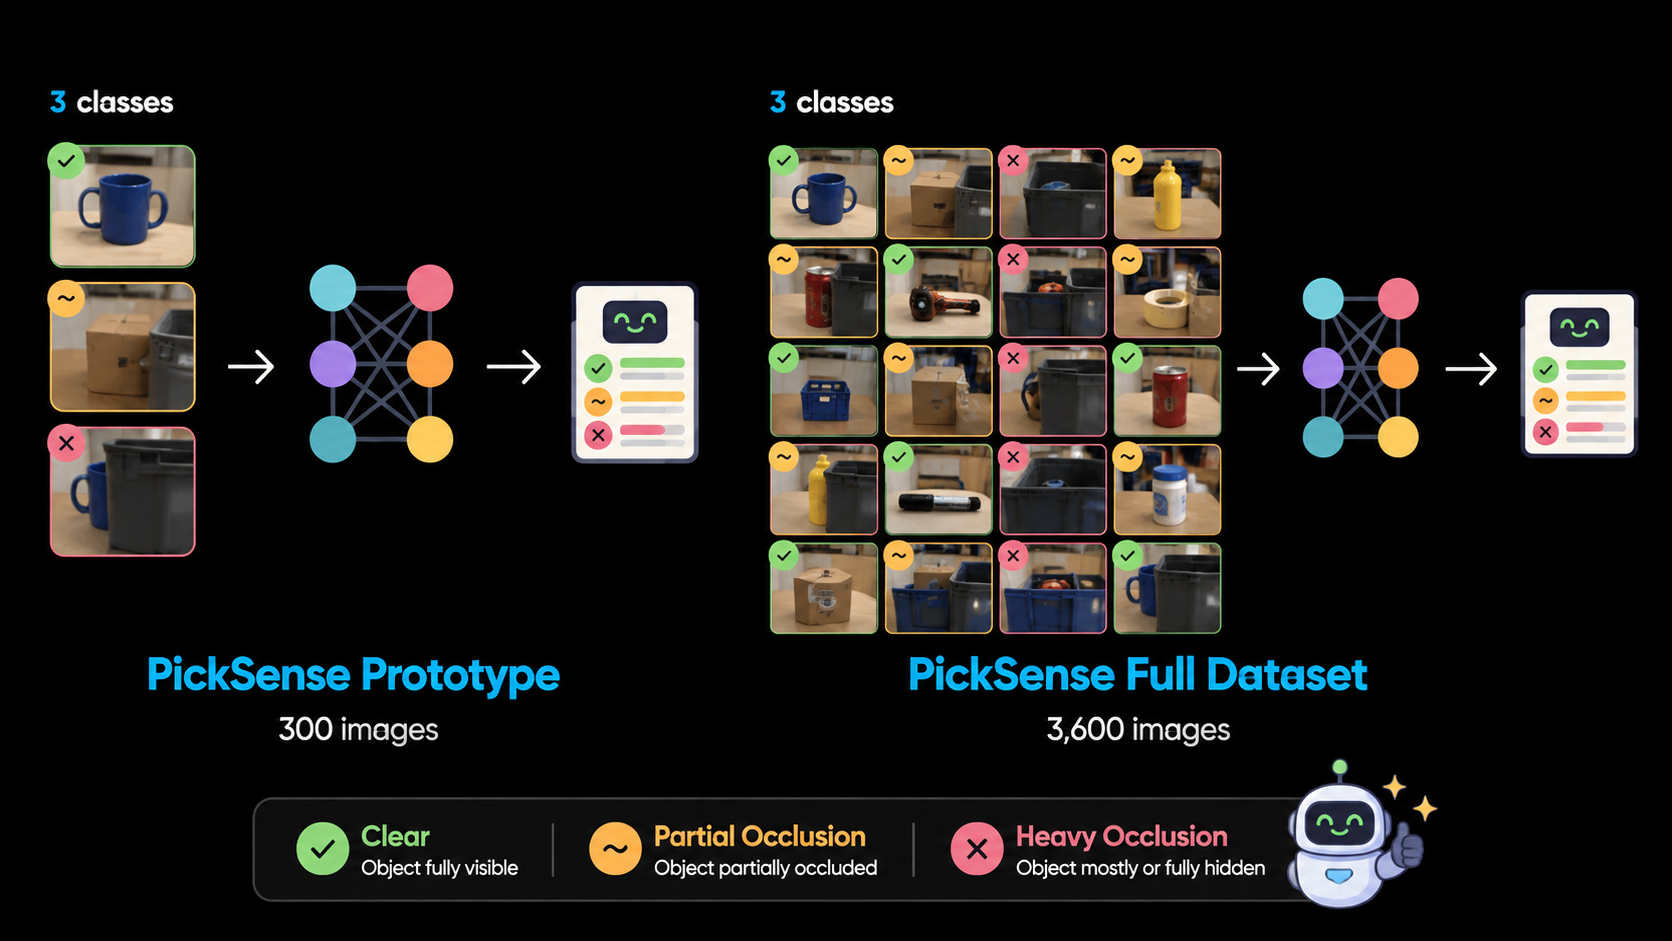

## 10.1 Creating a model and transforms for PickSense Big

In [ ]:
# Create an EfficientNet-B2 model for the three PickSense occlusion classes.
# num_classes=len(class_names),
# seed=42,
# )
#
# print("PickSense Big classes:", class_names)
# print("Classifier output features:", effnetb2_picksense_big.classifier[1].out_features)

In [ ]:
# from torchinfo import summary
#
# Summarize the PickSense Big EfficientNet-B2 feature extractor.
# summary(
#     effnetb2_picksense_big,
#     input_size=(1, 3, 224, 224),
#     col_names=["input_size", "output_size", "num_params", "trainable"],
#     col_width=20,
#     row_settings=["var_names"],
# )

## 10.2 Getting data for PickSense Big

In [ ]:
# from torchvision import datasets, transforms
#
# Reuse the prepared PickSense splits and apply stronger augmentation during training.
# picksense_big_train_transforms = transforms.Compose(
#     [
#         transforms.TrivialAugmentWide(num_magnitude_bins=31),
#         effnetb2_picksense_big_transforms,
#     ]
# )
#
# picksense_big_train_data = datasets.ImageFolder(
#     root=TRAIN_DIR,
#     transform=picksense_big_train_transforms,
# )
# picksense_big_test_data = datasets.ImageFolder(
#     root=TEST_DIR,
#     transform=effnetb2_picksense_big_transforms,
# )
#
# if picksense_big_train_data.classes != picksense_big_test_data.classes:
#     raise ValueError("PickSense training and test class mappings do not match.")
#
# print(f"PickSense Big training images: {len(picksense_big_train_data):,}")
# print(f"PickSense Big test images: {len(picksense_big_test_data):,}")
# print("Classes:", picksense_big_train_data.classes)

In [ ]:
# Get the PickSense Big class names in the exact ImageFolder index order.
# picksense_big_class_names = picksense_big_train_data.classes
# picksense_big_class_to_idx = picksense_big_train_data.class_to_idx
#
# print("PickSense Big class names:", picksense_big_class_names)
# print("Class-to-index mapping:", picksense_big_class_to_idx)

## 10.3 Creating a subset of the PickSense Big dataset for faster experimenting

In [ ]:
# from torch.utils.data import Dataset, Subset, random_split
#
#
# def split_dataset(
#     dataset: Dataset,
#     split_size: float = 0.2,
#     seed: int = 42,
# ) -> tuple[Subset, Subset]:
#     """Create reproducible experiment and remainder subsets from a dataset.
#
#     Args:
#         dataset: Dataset to split.
#         split_size: Fraction assigned to the experiment subset.
#         seed: Random seed used to reproduce the same split.
#
#     Returns:
#         The experiment subset and the remaining subset.
#     """
#     if not 0 < split_size < 1:
#         raise ValueError("split_size must be greater than 0 and less than 1.")
#     if len(dataset) < 2:
#         raise ValueError("dataset must contain at least two samples.")
#
#     experiment_length = max(1, int(len(dataset) * split_size))
#     remainder_length = len(dataset) - experiment_length
#     generator = torch.Generator().manual_seed(seed)
#
#     experiment_subset, remainder_subset = random_split(
#         dataset,
#         lengths=[experiment_length, remainder_length],
#         generator=generator,
#     )
#
#     print(
#         f"Split {len(dataset):,} samples into {experiment_length:,} "
#         f"({split_size:.0%}) for experimentation and {remainder_length:,} remaining."
#     )
#     return experiment_subset, remainder_subset

In [ ]:
# Create independent 20% experiment subsets from the existing PickSense train and test splits.
# PICKSENSE_BIG_SUBSET_FRACTION = 0.2
#
# picksense_big_train_subset, _ = split_dataset(
#     dataset=picksense_big_train_data,
#     split_size=PICKSENSE_BIG_SUBSET_FRACTION,
#     seed=42,
# )
# picksense_big_test_subset, _ = split_dataset(
#     dataset=picksense_big_test_data,
#     split_size=PICKSENSE_BIG_SUBSET_FRACTION,
#     seed=42,
# )
#
# print(f"Training subset: {len(picksense_big_train_subset):,} images")
# print(f"Test subset: {len(picksense_big_test_subset):,} images")
#
# len(picksense_big_train_subset), len(picksense_big_test_subset)

## 10.4 Turning the PickSense Big subsets into DataLoaders

The training loader shuffles the augmented 20% training subset, while the test loader evaluates the independent 20% test subset without shuffling. The original train/test boundary remains unchanged, preventing data leakage.

In [ ]:
# import os
# from torch.utils.data import DataLoader
#
# BATCH_SIZE = 32
# NUM_WORKERS = min(4, os.cpu_count() or 1)
# PIN_MEMORY = device == "cuda"
#
# Keep train and test subsets separate throughout loading and evaluation.
# picksense_big_train_dataloader = DataLoader(
#     picksense_big_train_subset,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     num_workers=NUM_WORKERS,
#     pin_memory=PIN_MEMORY,
# )
# picksense_big_test_dataloader = DataLoader(
#     picksense_big_test_subset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=NUM_WORKERS,
#     pin_memory=PIN_MEMORY,
# )
#
# print(f"Training batches: {len(picksense_big_train_dataloader)}")
# print(f"Test batches: {len(picksense_big_test_dataloader)}")
# print(f"Batch size: {BATCH_SIZE}, workers: {NUM_WORKERS}, pin memory: {PIN_MEMORY}")

## 10.5 Training the PickSense Big model

This experiment fine-tunes the three-class EfficientNet-B2 classifier head using stronger training augmentation and the reproducible PickSense subsets. ImageNet-pretrained feature layers remain frozen, so only the classifier parameters are optimized.

In [ ]:
# from going_modular.going_modular import engine
#
# PICKSENSE_BIG_EPOCHS = 5
#
# Optimize only the unfrozen EfficientNet-B2 classifier parameters.
# optimizer = torch.optim.Adam(
#     params=(
#         parameter
#         for parameter in effnetb2_picksense_big.parameters()
#         if parameter.requires_grad
#     ),
#     lr=1e-3,
# )
# loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
#
# set_seeds()
# picksense_big_results = engine.train(
#     model=effnetb2_picksense_big,
#     train_dataloader=picksense_big_train_dataloader,
#     test_dataloader=picksense_big_test_dataloader,
#     optimizer=optimizer,
#     loss_fn=loss_fn,
#     epochs=PICKSENSE_BIG_EPOCHS,
#     device=device,
# )

## 10.6 Inspecting PickSense Big training results

Plot the training and test loss and accuracy curves to check learning progress and identify overfitting.

In [ ]:
# from helper_functions import plot_loss_curves
#
# Visualize PickSense Big loss and accuracy across all training epochs.
# plot_loss_curves(picksense_big_results)

## 10.7 Saving and loading PickSense Big

Save the trained state dictionary to the persistent PickSense model directory, then reconstruct the same three-class architecture and reload it on CPU. This verifies that the checkpoint is portable and ready for later evaluation or deployment.

In [ ]:
# from going_modular.going_modular import utils
#
# PICKSENSE_BIG_MODEL_DIR = PROJECT_DIR / "models"
# PICKSENSE_BIG_MODEL_NAME = "pretrained_effnetb2_picksense_big.pth"
# PICKSENSE_BIG_MODEL_PATH = PICKSENSE_BIG_MODEL_DIR / PICKSENSE_BIG_MODEL_NAME
#
# utils.save_model(
#     model=effnetb2_picksense_big,
#     target_dir=PICKSENSE_BIG_MODEL_DIR,
#     model_name=PICKSENSE_BIG_MODEL_NAME,
# )
#
# print("Saved PickSense Big checkpoint:", PICKSENSE_BIG_MODEL_PATH)

In [ ]:
# Recreate the three-class architecture and load the saved checkpoint on CPU.
# loaded_effnetb2_picksense_big, loaded_picksense_big_transforms = create_effnetb2_model(
#     num_classes=len(picksense_big_class_names),
#     seed=42,
# )
#
# state_dict = torch.load(
#     PICKSENSE_BIG_MODEL_PATH,
#     map_location="cpu",
#     weights_only=True,
# )
# loaded_effnetb2_picksense_big.load_state_dict(state_dict)
# loaded_effnetb2_picksense_big.eval()
#
# print("Loaded PickSense Big checkpoint:", PICKSENSE_BIG_MODEL_PATH)
# print("Loaded model classes:", picksense_big_class_names)

## 10.8 Checking the PickSense Big model size

Report the saved checkpoint size in megabytes for comparison with the earlier PickSense EfficientNet-B2 and ViT checkpoints.

In [ ]:
# if not PICKSENSE_BIG_MODEL_PATH.is_file():
#     raise FileNotFoundError(
#         f"PickSense Big checkpoint not found at {PICKSENSE_BIG_MODEL_PATH}. "
#         "Run the saving cell first."
#     )
#
# picksense_big_model_size_mb = PICKSENSE_BIG_MODEL_PATH.stat().st_size / (1024 * 1024)
# print(f"PickSense Big EfficientNet-B2 checkpoint size: {picksense_big_model_size_mb:.1f} MB")

## 11. Turning PickSense Big into a deployable app

Package the trained PickSense Big EfficientNet-B2 model as a self-contained Gradio application for Hugging Face Spaces.

```text
demos/
└── picksense_big/
    ├── app.py
    ├── class_names.txt
    ├── examples/
    │   ├── clear_example.jpg
    │   ├── heavily_occluded_example.jpg
    │   └── partially_occluded_example.jpg
    ├── model.py
    ├── pretrained_effnetb2_picksense_big.pth
    └── requirements.txt
```

In [ ]:
# import shutil
# from pathlib import Path
#
# Recreate a clean, self-contained PickSense Big deployment directory.
# picksense_big_demo_path = Path("demos/picksense_big")
# if picksense_big_demo_path.exists():
#     shutil.rmtree(picksense_big_demo_path)
#
# picksense_big_examples_path = picksense_big_demo_path / "examples"
# picksense_big_examples_path.mkdir(parents=True, exist_ok=True)
#
# print("PickSense Big demo directory:", picksense_big_demo_path.resolve())

## 11.1 Adding representative examples and the trained checkpoint

Copy one deterministic test image from each PickSense class and copy—not move—the trained checkpoint so the original remains safely stored on Google Drive.

In [ ]:
# import random
# import shutil
#
# example_rng = random.Random(42)
#
# Copy one representative test image from each PickSense class.
# for class_name in picksense_big_class_names:
#     class_images = sorted(
#         path
#         for path in (TEST_DIR / class_name).iterdir()
#         if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
#     )
#     if not class_images:
#         raise FileNotFoundError(f"No test images found for class: {class_name}")
#
#     source_path = example_rng.choice(class_images)
#     destination_path = picksense_big_examples_path / f"{class_name}_example{source_path.suffix.lower()}"
#     shutil.copy2(source_path, destination_path)
#     print(f"Copied example: {destination_path}")
#
# Preserve the persistent checkpoint and place a copy in the deployment folder.
# picksense_big_deployment_model_path = picksense_big_demo_path / PICKSENSE_BIG_MODEL_NAME
# shutil.copy2(PICKSENSE_BIG_MODEL_PATH, picksense_big_deployment_model_path)
#
# if picksense_big_deployment_model_path.stat().st_size != PICKSENSE_BIG_MODEL_PATH.stat().st_size:
#     raise IOError("The deployment checkpoint does not match the saved source checkpoint.")
#
# print("Copied checkpoint:", picksense_big_deployment_model_path)

## 11.2 Saving the PickSense class names

Store class names in the exact `ImageFolder` index order used during training so deployment probabilities map to the correct labels.

In [ ]:
# Confirm the exact output-label order before writing it to the app.
# picksense_big_class_names

In [ ]:
# picksense_big_class_names_path = picksense_big_demo_path / "class_names.txt"
# picksense_big_class_names_path.write_text(
#     "\n".join(picksense_big_class_names) + "\n",
#     encoding="utf-8",
# )
#
# print("Saved PickSense class names:", picksense_big_class_names_path)

In [ ]:
# loaded_picksense_big_class_names = [
#     class_name.strip()
#     for class_name in picksense_big_class_names_path.read_text(encoding="utf-8").splitlines()
#     if class_name.strip()
# ]
#
# if loaded_picksense_big_class_names != picksense_big_class_names:
#     raise ValueError("Saved PickSense class order does not match the training class order.")
#
# loaded_picksense_big_class_names

## 11.3 Creating the PickSense Big model module (`model.py`)

Reconstruct EfficientNet-B2 without downloading ImageNet weights at app startup. The complete trained state dictionary is loaded by the application.

In [ ]:
# %%writefile demos/picksense_big/model.py
# """Model factory for the deployable PickSense Big classifier."""
#
# import torch
# import torchvision
# from torch import nn
#
#
# def create_effnetb2_model(num_classes: int = 3, seed: int = 42):
#     """Create the EfficientNet-B2 architecture and inference transforms."""
#     weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
#     inference_transforms = weights.transforms()
#
#     The app loads a complete trained state dictionary, so no download is required.
#     model = torchvision.models.efficientnet_b2(weights=None)
#
#     torch.manual_seed(seed)
#     model.classifier = nn.Sequential(
#         nn.Dropout(p=0.3, inplace=True),
#         nn.Linear(in_features=1408, out_features=num_classes),
#     )
#
#     return model, inference_transforms

## 11.4 Creating the PickSense Big Gradio application (`app.py`)

The application:

1. Loads class names in training order from `class_names.txt`.
2. Reconstructs the three-class EfficientNet-B2 architecture and loads `pretrained_effnetb2_picksense_big.pth` on CPU.
3. Converts uploaded images to RGB, applies the official inference transforms, and returns all three class probabilities plus inference time.
4. Discovers representative examples relative to the application directory, making deployment independent of the current working directory.

In [ ]:
# %%writefile demos/picksense_big/app.py
# """Gradio app for the PickSense Big visual occlusion classifier."""
#
# from pathlib import Path
# from timeit import default_timer as timer
#
# import gradio as gr
# import torch
# from PIL import Image
#
# from model import create_effnetb2_model
#
#
# APP_DIR = Path(__file__).resolve().parent
# MODEL_PATH = APP_DIR / "pretrained_effnetb2_picksense_big.pth"
# CLASS_NAMES_PATH = APP_DIR / "class_names.txt"
# EXAMPLES_DIR = APP_DIR / "examples"
# IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
#
# CLASS_NAMES = [
#     class_name.strip()
#     for class_name in CLASS_NAMES_PATH.read_text(encoding="utf-8").splitlines()
#     if class_name.strip()
# ]
# if not CLASS_NAMES:
#     raise ValueError("class_names.txt must contain at least one class name.")
#
# model, inference_transforms = create_effnetb2_model(num_classes=len(CLASS_NAMES))
# state_dict = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
# model.load_state_dict(state_dict)
# model.eval()
#
#
# def predict(image: Image.Image) -> tuple[dict[str, float], float]:
#     """Return PickSense occlusion probabilities and CPU inference time."""
#     if image is None:
#         raise ValueError("Upload an image before running prediction.")
#
#     start_time = timer()
#     image_tensor = inference_transforms(image.convert("RGB")).unsqueeze(0)
#
#     with torch.inference_mode():
#         probabilities = torch.softmax(model(image_tensor), dim=1)[0]
#
#     predictions = {
#         class_name: float(probabilities[index])
#         for index, class_name in enumerate(CLASS_NAMES)
#     }
#     return predictions, round(timer() - start_time, 5)
#
#
# example_list = [
#     [str(path)]
#     for path in sorted(EXAMPLES_DIR.iterdir())
#     if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
# ]
#
# TITLE = "PickSense Big — Visual Occlusion Classifier"
# DESCRIPTION = (
#     "Upload an object image to estimate whether it is clear, partially occluded, "
#     "or heavily occluded using a transfer-learned EfficientNet-B2 model."
# )
# ARTICLE = (
#     "PickSense uses visual occlusion as a proxy for pickability. It does not directly "
#     "measure grasp geometry, reachability, collision risk, or physical grasp success."
# )
#
# demo = gr.Interface(
#     fn=predict,
#     inputs=gr.Image(type="pil", label="Object image"),
#     outputs=[
#         gr.Label(num_top_classes=len(CLASS_NAMES), label="Occlusion probabilities"),
#         gr.Number(label="Prediction time (seconds)"),
#     ],
#     examples=example_list,
#     title=TITLE,
#     description=DESCRIPTION,
#     article=ARTICLE,
# )
#
#
# if __name__ == "__main__":
#     demo.launch()

## 11.5 Creating the PickSense Big requirements file (`requirements.txt`)

Pin the versions used by this notebook so Hugging Face Spaces can reproduce the deployment environment.

In [ ]:
# %%writefile demos/picksense_big/requirements.txt
# torch==2.11.0
# torchvision==0.26.0
# gradio==6.26.0
# Pillow==11.3.0

## 11.6 Validating and packaging the PickSense Big app

Check that every required deployment asset exists, create a ZIP whose files are located at the archive root as expected by Hugging Face Spaces, and start a download in Google Colab.

In [ ]:
# from zipfile import ZIP_DEFLATED, ZipFile
#
# picksense_big_zip_path = Path("demos/picksense_big.zip")
# required_paths = [
#     picksense_big_demo_path / "app.py",
#     picksense_big_demo_path / "model.py",
#     picksense_big_demo_path / "requirements.txt",
#     picksense_big_demo_path / "class_names.txt",
#     picksense_big_demo_path / PICKSENSE_BIG_MODEL_NAME,
#     picksense_big_examples_path,
# ]
# missing_paths = [str(path) for path in required_paths if not path.exists()]
# if missing_paths:
#     raise FileNotFoundError("Missing deployment assets: " + ", ".join(missing_paths))
#
# example_files = [
#     path
#     for path in picksense_big_examples_path.iterdir()
#     if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
# ]
# if len(example_files) != len(picksense_big_class_names):
#     raise ValueError("Expected one deployment example for each PickSense class.")
#
# excluded_parts = {"__pycache__", ".ipynb_checkpoints"}
# excluded_suffixes = {".pyc", ".ipynb"}
# with ZipFile(picksense_big_zip_path, "w", compression=ZIP_DEFLATED) as archive:
#     for path in sorted(picksense_big_demo_path.rglob("*")):
#         if (
#             path.is_file()
#             and not excluded_parts.intersection(path.parts)
#             and path.suffix.lower() not in excluded_suffixes
#         ):
#             archive.write(path, arcname=path.relative_to(picksense_big_demo_path))
#
# print("Created PickSense Big archive:", picksense_big_zip_path.resolve())
# print(f"Archive size: {picksense_big_zip_path.stat().st_size / (1024 * 1024):.1f} MB")
#
# try:
#     from google.colab import files
# except ImportError:
#     print("Not running in Google Colab; download the ZIP manually.")
# else:
#     files.download(str(picksense_big_zip_path))

## 11.7 Deploying PickSense Big to Hugging Face Spaces

1. Create a new Hugging Face Space and select **Gradio** as the SDK.
2. Upload the extracted contents of `picksense_big.zip` at the repository root—not inside an extra folder.
3. Confirm that `app.py`, `model.py`, `requirements.txt`, `class_names.txt`, the checkpoint, and `examples/` are present.
4. Wait for the Space to install dependencies and build the app.
5. Set the username and Space name below to embed the live deployment.

In [ ]:
# from IPython.display import IFrame, display
#
# Replace the placeholder after deploying the PickSense Big Space.
# HF_USERNAME = "YOUR_USERNAME"
# HF_PICKSENSE_BIG_SPACE_NAME = "picksense-big"
#
# if HF_USERNAME == "YOUR_USERNAME":
#     print(
#         "Set HF_USERNAME to your Hugging Face username, then rerun this cell "
#         "to embed the deployed PickSense Big app."
#     )
# else:
#     picksense_big_space_url = (
#         f"https://{HF_USERNAME}-{HF_PICKSENSE_BIG_SPACE_NAME}.hf.space"
#     )
#     print("Embedding PickSense Big Space:", picksense_big_space_url)
#     display(IFrame(src=picksense_big_space_url, width="100%", height=750))